In [76]:
using LinearAlgebra
using PythonPlot
using Random
using NPZ

In [77]:
xtraj = npzread("xtraj.npy")
q_true = npzread("q_true.npy")

4×600 Matrix{Float64}:
 1.0   0.998605      0.994424    …  0.996286     0.99035     0.981652
 0.0   0.0527929     0.105443       0.0860451    0.138531    0.190627
 0.0   0.000606461   0.00125219     0.00326459   0.00389691  0.00446307
 0.0  -0.000216068  -0.00035027     0.000103156  0.00018598  0.00033555

In [78]:
#quaternion functions
function hat(v)
    return [0 -v[3] v[2];
            v[3] 0 -v[1];
            -v[2] v[1] 0]
end

function unhat(S)
    return 0.5*[S[3,2]-S[2,3];
                S[1,3]-S[3,1];
                S[2,1]-S[1,2]]
end

H = [zeros(1,3); I];
T = [1  zeros(1,3);
     zeros(3,1) -I];

function L(q)
    return [q[1]          -q[2:4]';
            q[2:4]    q[1]*I + hat(q[2:4])]
end

function R(q)
    return [q[1]          -q[2:4]';
            q[2:4]    q[1]*I - hat(q[2:4])]
end

function G(q)
    return L(q)*H
end

function Q(q)
    return H'*(R(q)'*L(q))*H
end

function expq(ϕ)
    θ = norm(ϕ)
    return [cos(θ); ϕ*sinc(θ/π)];
end

expq (generic function with 1 method)

In [ ]:
size(q_true, 4)

()

In [93]:
h = 0.1 #time step
n = 600 #number of time steps
tf = n*h #final time

#sample random initial attitude
q0 = randn(4)
q0 = q0/norm(q0)

#sample random angular velocity
ω0 = 0.1*randn(3)

x0 = [q0; ω0];

FieldError: FieldError: type Array has no field `shape`, available fields: `ref`, `size`

In [80]:
S_SRU = Diagonal([4.85e-6^2, 4.85e-6^2, 3.88e-5^2])
S_CSS = Diagonal([0.017^2, 0.017^2, 0.017^2])

S_list = [S_SRU, S_SRU, S_CSS, S_CSS]

m = length(S_list)
W = 0.01*I(3*m) #measurement noise
V = 0.01*I(3) #process noise

3×3 Diagonal{Float64, Vector{Float64}}:
 0.01   ⋅     ⋅ 
  ⋅    0.01   ⋅ 
  ⋅     ⋅    0.01

In [81]:
#generate noisy gyro measurements
gyro = zeros(3,n)
for k = 1:n
    gyro[:,k] = xtraj[5:7] + sqrt(V)*randn(3)
end

In [82]:
#generate random inertial vectors
r_N = zeros(3,m)
for ℓ = 1:m
    r_N[:,ℓ] = randn(3)
    r_N[:,ℓ] = r_N[:,ℓ]/norm(r_N[:,ℓ])
end

In [83]:
using Distributions

ytraj = zeros(3*m,n)

for k = 1:n
    Qk = Q(xtraj[1:4,k])
    yk = zeros(3,m)

    for ℓ = 1:m
        # True body-frame vector
        rB_true = Qk' * r_N[:,ℓ]

        # Sensor-specific noise
        noise = rand(MvNormal(zeros(3), S_list[ℓ]))

        # Add noise and renormalize
        rB_noisy = rB_true + noise
        yk[:,ℓ] = rB_noisy / norm(rB_noisy)
    end

    ytraj[:,k] .= vec(yk)   # column stacking (Julia default)
end

In [84]:
function state_prediction(q,ω,h)
    Δq = expq(0.5*h*ω)
    return L(q)*Δq
end

function state_prediction_deriv(q,ω,h)
    Δq = expq(0.5*h*ω)
    qn = L(q)*Δq
    return G(qn)'*R(Δq)*G(q)
end

state_prediction_deriv (generic function with 1 method)

In [85]:
function measurement_prediction(q,r_N)
    Qk = Q(q)
    y = Qk'*r_N
    return y[:]
end

function measurement_prediction_deriv(q,r_N)
    m = size(r_N,2)
    C = zeros(3*m,3)
    for k = 1:m
        C[((k-1)*3).+(1:3),:] .= H'*(L(q)'*L(H*r_N[:,k]) + R(q)*R(H*r_N[:,k])*T)*G(q)
    end
    return C
end

measurement_prediction_deriv (generic function with 1 method)

In [86]:
# Filter Initialization
xfilt = zeros(4, n)
xfilt[:,1] = q0+0.1*randn(4)
xfilt[:,1] = xfilt[:,1]/norm(xfilt[:,1])

P = zeros(3,3,n)
P[:,:,1] .= 0.5*I(3)

3×3 view(::Array{Float64, 3}, :, :, 1) with eltype Float64:
 0.5  0.0  0.0
 0.0  0.5  0.0
 0.0  0.0  0.5

In [87]:
for k = 1:(n-1)
    #Prediction
    xpred = state_prediction(xfilt[:,k],gyro[:,k],h)
    A = state_prediction_deriv(xfilt[:,k],gyro[:,k],h)
    Ppred = A*P[:,:,k]*A' + V

    #Innovation
    z = ytraj[:,k+1] - measurement_prediction(xpred,r_N)
    C = measurement_prediction_deriv(xpred,r_N)
    S = C*Ppred*C' + W

    #Kalman Gain
    K = Ppred*C'/S

    #Update
    ϕ = K*z
    Δq = [sqrt(1-ϕ'*ϕ); ϕ]
    xfilt[:,k+1] = L(xpred)*Δq
    
    P[:,:,k+1] = (I(3) - K*C)*Ppred*(I(3) - K*C)' + K*W*K'
end

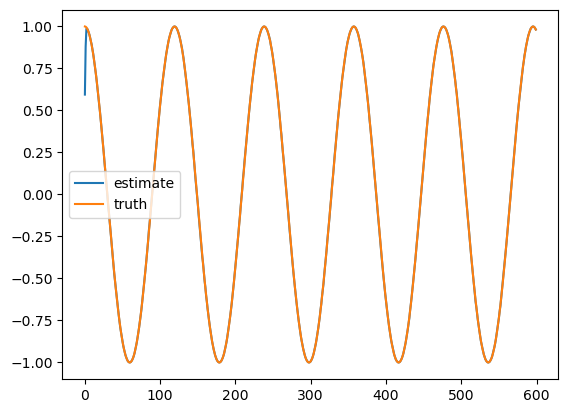

In [88]:
using PythonPlot

figure()
plot(xfilt[1,:], label="estimate")
plot(xtraj[1,:], label="truth")
legend()

display(gcf())

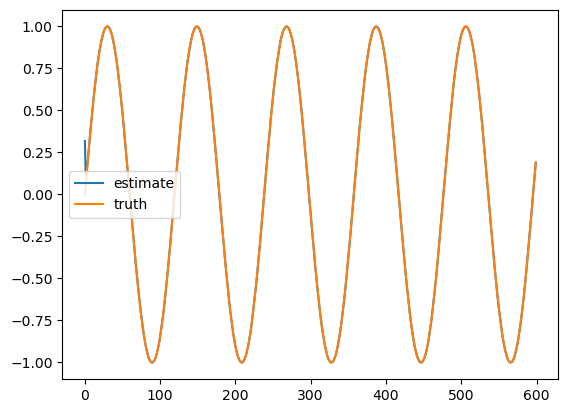

In [89]:
using PythonPlot

figure()
plot(xfilt[2,:], label="estimate")
plot(xtraj[2,:], label="truth")
legend()

display(gcf())

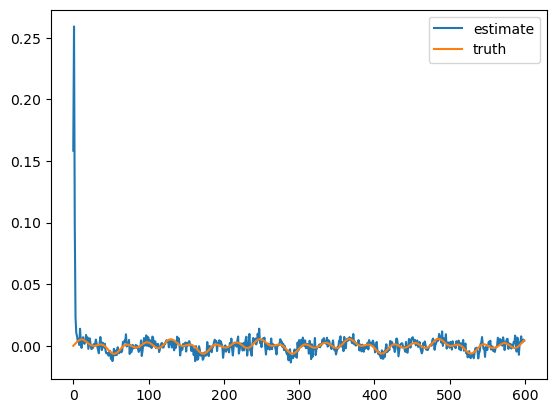

In [90]:
using PythonPlot

figure()
plot(xfilt[3,:], label="estimate")
plot(xtraj[3,:], label="truth")
legend()

display(gcf())

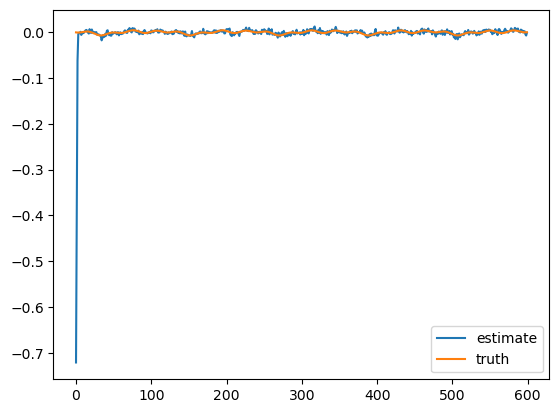

In [91]:
using PythonPlot

figure()
plot(xfilt[4,:], label="estimate")
plot(xtraj[4,:], label="truth")
legend()

display(gcf())

In [92]:
using NPZ
npzwrite("xfilt.npy", xfilt)
npzwrite("P.npy", P)
npzwrite("ytraj.npy", ytraj)
npzwrite("r_N.npy", r_N)
npzwrite("gyro.npy", gyro)